<a href="https://colab.research.google.com/github/roraashibaa39-glitch/itanic-raghad/blob/main/itanic%F0%9F%9A%A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import accuracy_score

In [2]:
!unzip /content/titanic.zip

Archive:  /content/titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [3]:
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_data.shape

(891, 12)

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print(train_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
train_data['Age']=train_data['Age'].fillna(train_data['Age'].mean())

In [9]:
train_data= train_data.drop(['Cabin'],axis=1)

In [10]:
print(train_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [11]:
train_data['Embarked']=train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

In [12]:
print(train_data.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Visualization

In [13]:
print(train_data['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
sns.set

<function seaborn.rcmod.set(*args, **kwargs)>

<Axes: xlabel='Survived', ylabel='count'>

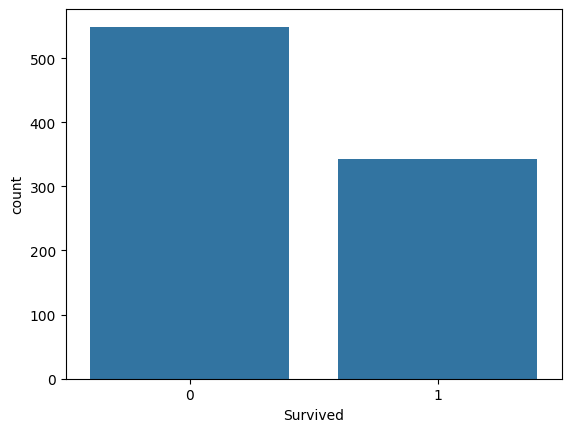

In [15]:
sns.countplot(x='Survived',data=train_data)

In [16]:
print(train_data['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


<Axes: xlabel='Sex', ylabel='count'>

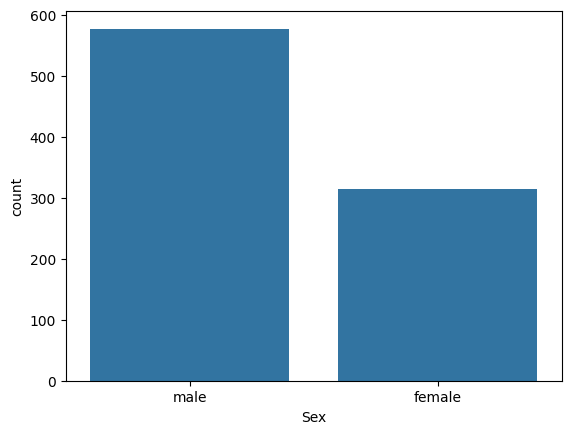

In [17]:
sns.countplot(x='Sex',data=train_data)

<Axes: xlabel='Sex', ylabel='count'>

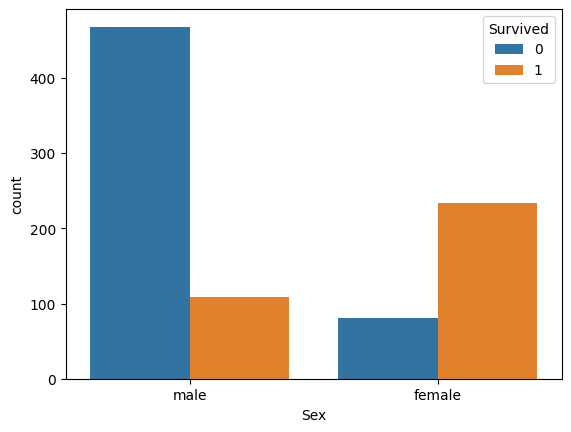

In [18]:
sns.countplot(x='Sex',hue='Survived',data=train_data)

<Axes: xlabel='Pclass', ylabel='count'>

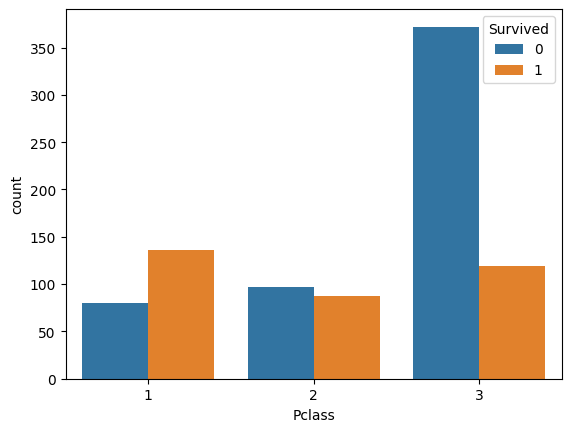

In [19]:
sns.countplot(x='Pclass',hue='Survived',data=train_data)

Encoding

In [20]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [21]:
train_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked': {'S':0,'C':1, 'Q':2}}, inplace=True)

/tmp/ipython-input-2789315673.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked': {'S':0,'C':1, 'Q':2}}, inplace=True)


In [22]:
X_train=train_data.drop(columns=['PassengerId','Survived', 'Name','Ticket'],axis=1)
Y_train=train_data['Survived']

In [23]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [24]:
Y_train.head()

,Survived
0,0
1,1
2,1
3,1
4,0


Modeling using logisic Regression


In [25]:
Model = LogisticRegression()

In [26]:
Model.fit(X_train,Y_train)

LogisticRegression()

In [27]:
X_train_prediction = Model.predict(X_train)
training_accuracy = accuracy_score(Y_train,X_train_prediction)
print(training_accuracy)

0.8047138047138047


In [28]:
from sklearn.metrics import classification_report
print(classification_report(Y_train,X_train_prediction))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       549
           1       0.77      0.71      0.74       342

    accuracy                           0.80       891
   macro avg       0.80      0.79      0.79       891
weighted avg       0.80      0.80      0.80       891



Modeling using: Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier
Model_dt = DecisionTreeClassifier()

In [30]:
Model_dt.fit(X_train,Y_train)

DecisionTreeClassifier()

In [31]:
X_train_prediction_dt = Model_dt.predict(X_train)
training_accuracy_dt = accuracy_score(Y_train,X_train_prediction_dt)
print(training_accuracy_dt)

0.9820426487093153


In [32]:
from sklearn.metrics import classification_report
print(classification_report(Y_train,X_train_prediction_dt))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       549
           1       0.99      0.96      0.98       342

    accuracy                           0.98       891
   macro avg       0.98      0.98      0.98       891
weighted avg       0.98      0.98      0.98       891



Test Prerocessing

In [33]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [34]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [35]:
print(test_data.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


Fill Null Values in Test

In [36]:
test_data['Age']=test_data['Age'].fillna(test_data['Fare'].mean())

In [37]:
test_data['Fare']=test_data['Fare'].fillna(test_data['Fare'].mean())

In [38]:
test_data=test_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}})

/tmp/ipython-input-1264589589.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data=test_data.replace({'Sex':{'male':0, 'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}})


In [39]:
test_data.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,2
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0
5,897,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NaN,0
6,898,3,"Connolly, Miss. Kate",1,30.0,0,0,330972,7.6292,NaN,2
7,899,2,"Caldwell, Mr. Albert Francis",0,26.0,1,1,248738,29.0000,NaN,0
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",1,18.0,0,0,2657,7.2292,NaN,1
9,901,3,"Davies, Mr. John Samuel",0,21.0,2,0,A/4 48871,24.1500,NaN,0


In [40]:
test_data.drop(columns=['Cabin','PassengerId','Name','Ticket'],axis=1,inplace=True)

In [41]:
print(test_data.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    0  34.5      0      0   7.8292         2
1       3    1  47.0      1      0   7.0000         0
2       2    0  62.0      0      0   9.6875         2
3       3    0  27.0      0      0   8.6625         0
4       3    1  22.0      1      1  12.2875         0


Inference

In [44]:
label ={0: "Not Survived", 1: "Survived"}

Pclass = int(input("Enter class of the passenger (1, 2, 3): "))
Sex = int(input("Enter sex of the passenger (1 = female, 0 = male): "))
Age = float(input("Enter age of the passenger: "))
SibSp = int(input("Enter number of siblings/spouses aboard: "))
Parch = int(input("Enter number of parents/children aboard: "))
Fare = float(input("Enter fare of the passenger: "))
Embarked = int(input("Enter port of embarkation (1 = Cherbourg, 2 = Queenstown, 0 = Southampton "))

# 3. Prepare input in the format expected by the model
input_data = np.array([[Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]])

# 4. Make prediction
prediction = Model_dt.predict(input_data)[0]

# 5. Translate prediction to human-readable format
result = label[prediction]

# 6. Print full explanation
print("__________________________________________________________________________________________________________________________________________")
print("🚢🌊 Titanic Survival Prediction:")
print("The Person with:")
print(f"Class: {Pclass}, Sex: {'Male' if Sex == 0 else 'Female'}, Age: {Age}, SibSp: {SibSp}, Parch: {Parch}, Fare: {Fare}, Embarked: {Embarked}")
print(f"Prediction: {result}")

Enter class of the passenger (1, 2, 3): 3
Enter sex of the passenger (1 = female, 0 = male): 0
Enter age of the passenger: 21.0
Enter number of siblings/spouses aboard: 2
Enter number of parents/children aboard: 0
Enter fare of the passenger: 24.1500
Enter port of embarkation (1 = Cherbourg, 2 = Queenstown, 0 = Southampton 0
__________________________________________________________________________________________________________________________________________
🚢🌊 Titanic Survival Prediction:
The Person with:
Class: 3, Sex: Male, Age: 21.0, SibSp: 2, Parch: 0, Fare: 24.15, Embarked: 0
Prediction: Not Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
